# Initial definition and testing of the circuit


Samples in computational basis:
[0.    0.    0.001 0.012 0.01  0.011 0.    0.002 0.001 0.007 0.003 0.
 0.009 0.002 0.018 0.013 0.002 0.    0.001 0.004 0.003 0.    0.001 0.
 0.001 0.012 0.009 0.001 0.006 0.002 0.009 0.003 0.    0.001 0.    0.006
 0.002 0.004 0.002 0.    0.008 0.013 0.002 0.    0.013 0.003 0.013 0.018
 0.004 0.    0.001 0.005 0.    0.    0.003 0.    0.003 0.004 0.003 0.
 0.005 0.003 0.    0.    0.002 0.    0.004 0.006 0.004 0.016 0.003 0.
 0.    0.002 0.004 0.003 0.001 0.007 0.007 0.    0.001 0.    0.    0.
 0.009 0.015 0.    0.    0.002 0.005 0.001 0.002 0.006 0.007 0.    0.003
 0.    0.    0.008 0.    0.002 0.005 0.001 0.004 0.    0.003 0.012 0.009
 0.    0.002 0.016 0.004 0.004 0.006 0.01  0.004 0.    0.001 0.008 0.
 0.003 0.004 0.    0.006 0.008 0.005 0.003 0.005 0.003 0.01  0.002 0.
 0.005 0.008 0.003 0.001 0.011 0.002 0.001 0.    0.001 0.    0.002 0.
 0.002 0.001 0.002 0.    0.    0.    0.01  0.    0.018 0.014 0.002 0.001
 0.003 0.002 0.003 0.    0.012 0.    0.    

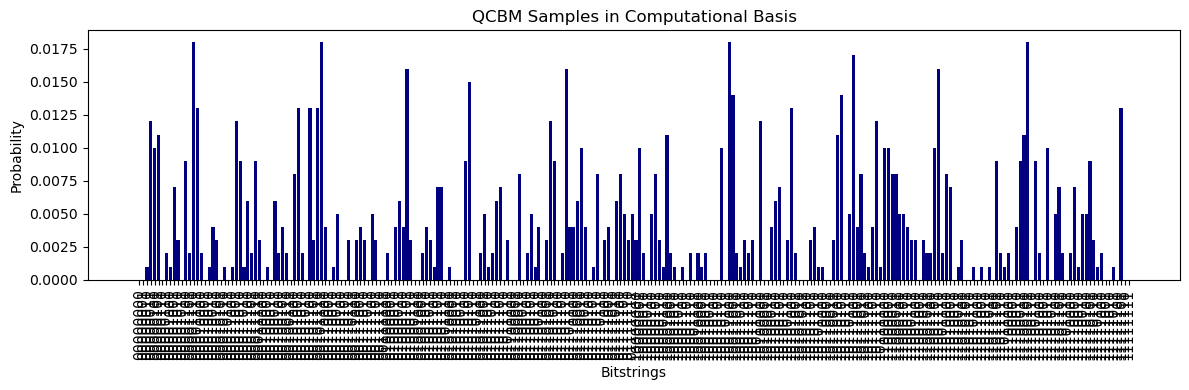

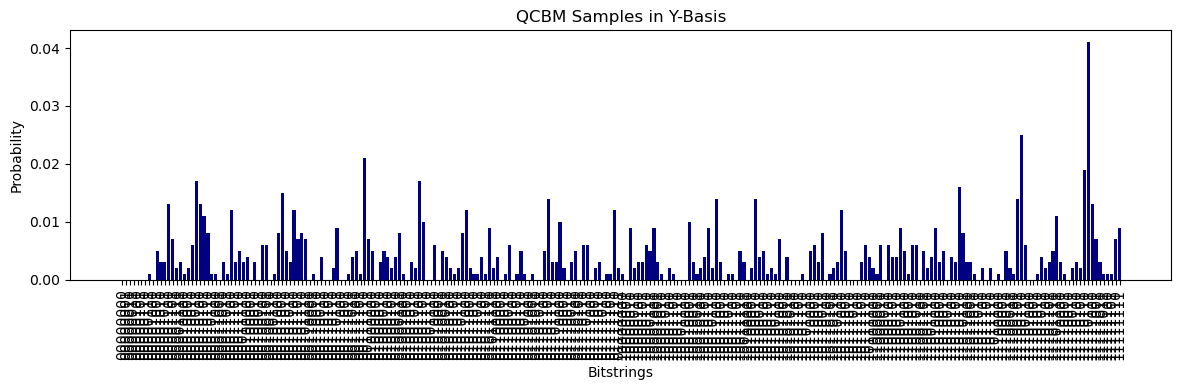

In [1]:
#Quantum Circuit Born Machine 
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

num_qubits = 8
num_layers = 2
num_samples = 1000

# Define pennylane device

dev = qml.device("default.qubit", wires=num_qubits, shots=num_samples)

def qcbm_ansatz(params):
    param_idx = 0
    # Create specified number of layers
    for _ in range(num_layers):
        # Variational section - parametrized rotation gates
        for qubit in range(num_qubits):
            qml.RX(params[param_idx], wires=qubit)
            param_idx += 1
            qml.RZ(params[param_idx], wires=qubit)
            param_idx += 1

        # All-to-all entanglement layer (for simulation)
        for i in range(num_qubits):
            for j in range(i+1, num_qubits):
                qml.IsingXX(params[param_idx], wires=[i, j])
                param_idx += 1

        # # Nearest-neighbor entanglement layer (for experimental implementation)
        # for i in range(num_qubits - 1):
        #     qml.IsingXX(params[param_idx], wires=[i, i + 1])
        #     param_idx += 1


# Quantum circuit definition
@qml.qnode(dev)
def circuit(params, basis="computational"):
    # Use the ansatz template
    qcbm_ansatz(params)

    # Add rotations to measure on different basis, if specified
    if basis == "Y":
        for qubit in range(num_qubits):
            qml.RX(np.pi / 2, wires=qubit)

    # Take samples
    return qml.probs(wires=range(num_qubits))


# Initialize the circuit parameters
num_params = num_layers * (2 * num_qubits + num_qubits * (num_qubits - 1) // 2)
params = np.random.uniform(0, 2 * np.pi, num_params)

# Run the circuit to get samples in both computational and Y-basis
samples_computational = circuit(params, basis="computational")
samples_Y_basis = circuit(params, basis="Y")

# Print sample outputs
print("Samples in computational basis:")
print(samples_computational)

print("\nSamples in Y-basis:")
print(samples_Y_basis)


# Plot the samples (now works for probability vectors, not bitstring samples)
def plot_sample_distribution(probabilities, title):
    n = int(np.log2(len(probabilities)))
    bitstrings = [format(i, f'0{n}b') for i in range(len(probabilities))]
    plt.figure(figsize=(12, 4))
    plt.bar(bitstrings, probabilities, color='navy')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Bitstrings")
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()

# Visualize results
plot_sample_distribution(samples_computational, "QCBM Samples in Computational Basis")
plot_sample_distribution(samples_Y_basis, "QCBM Samples in Y-Basis")

# Training a very simple version of it


Total parameters: 7
Training QCBM with 4 qubits, 1 layer(s)
Parameter count: 7


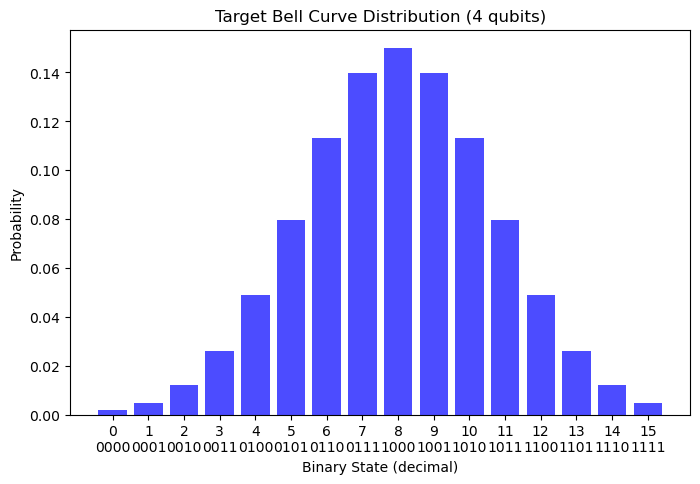

Target entropy: 2.3825
Starting simple training...
Iteration 0: Loss = 1.047364
Iteration 20: Loss = 0.453500
Iteration 20: Loss = 0.453500
Iteration 40: Loss = 0.258340
Iteration 40: Loss = 0.258340
Iteration 60: Loss = 0.155384
Iteration 60: Loss = 0.155384
Iteration 80: Loss = 0.121915
Iteration 80: Loss = 0.121915
Iteration 100: Loss = 0.106563
Iteration 100: Loss = 0.106563
Iteration 120: Loss = 0.099244
Iteration 120: Loss = 0.099244
Iteration 140: Loss = 0.092666
Iteration 140: Loss = 0.092666
Iteration 160: Loss = 0.091026
Iteration 160: Loss = 0.091026
Iteration 180: Loss = 0.089033
Iteration 180: Loss = 0.089033
Iteration 200: Loss = 0.087634
Iteration 200: Loss = 0.087634
Iteration 220: Loss = 0.088055
Iteration 220: Loss = 0.088055
Iteration 240: Loss = 0.087346
Iteration 240: Loss = 0.087346
Iteration 260: Loss = 0.086353
Iteration 260: Loss = 0.086353
Iteration 280: Loss = 0.087055
Iteration 280: Loss = 0.087055
Iteration 300: Loss = 0.084584
Iteration 300: Loss = 0.08458

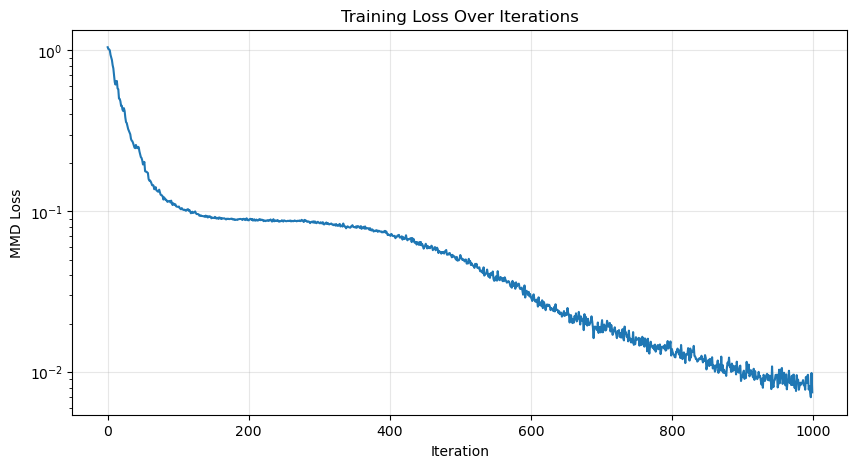


Training completed!
Final loss: 0.007467

Model Evaluation:
MMD Loss: 0.008713
KL Divergence: 0.1137


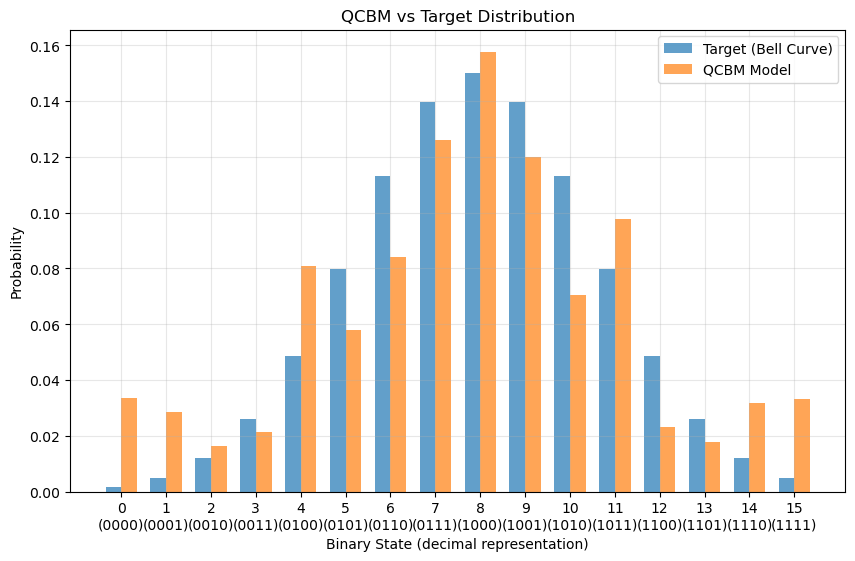


Trained parameters: [ 1.67931169 -2.22679734  1.3250808   1.41289079 -0.20126319  0.40298965
  0.31028402]
Parameter magnitudes: [1.67931169 2.22679734 1.3250808  1.41289079 0.20126319 0.40298965
 0.31028402]


In [32]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Configuration - Start simpler
num_qubits = 4  # Start smaller to avoid barren plateaus
num_layers = 1  # Start with 1 layer
num_samples = 5000  # More samples for better probability estimation

# Calculate number of parameters - simplified ansatz
# Each layer: num_qubits rotations + nearest neighbor entanglement
params_per_layer = num_qubits + (num_qubits - 1)  # RY rotations + CNOT gates
total_params = num_layers * params_per_layer
print(f"Total parameters: {total_params}")

# Define pennylane device
dev = qml.device("default.qubit", wires=num_qubits, shots=num_samples)

def simple_qcbm_ansatz(params):
    """Simplified ansatz to avoid barren plateaus"""
    param_idx = 0
    
    for layer in range(num_layers):
        # Single rotation per qubit (RY gates are often most expressive)
        for qubit in range(num_qubits):
            qml.RY(params[param_idx], wires=qubit)
            param_idx += 1
        
        # Nearest-neighbor entanglement only
        for i in range(num_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

# Quantum circuit definition
@qml.qnode(dev)
def simple_circuit(params):
    simple_qcbm_ansatz(params)
    return qml.probs(wires=range(num_qubits))

def generate_simple_bell_curve(num_bits=4):
    """
    Generate a simpler bell curve for fewer qubits
    """
    num_states = 2**num_bits
    
    # Create bell curve centered at middle state
    center = num_states // 2
    states = np.arange(num_states)
    
    # Use Gaussian centered at middle with appropriate width
    sigma = num_states / 6  # Standard deviation
    probs = np.exp(-(states - center)**2 / (2 * sigma**2))
    probs = probs / np.sum(probs)  # Normalize
    
    return probs

def mmd_loss(target_probs, model_probs):
    """
    Maximum Mean Discrepancy - alternative to KL divergence
    Often works better for probability matching
    """
    return np.sum((target_probs - model_probs)**2)

def train_qcbm_simple(target_probs, num_iterations=200):
    """
    Simple parameter-shift rule training (more suitable for quantum circuits)
    """
    # Better initialization: small values around pi/4
    params = np.random.uniform(-np.pi/8, np.pi/8, total_params)
    
    learning_rate = 0.1
    losses = []
    
    print("Starting simple training...")
    
    for iteration in range(num_iterations):
        # Get current model probabilities
        current_probs = simple_circuit(params)
        
        # Calculate loss
        loss = mmd_loss(target_probs, current_probs)
        losses.append(loss)
        
        if iteration % 20 == 0:
            print(f"Iteration {iteration}: Loss = {loss:.6f}")
        
        # Simple finite difference gradients
        gradients = np.zeros_like(params)
        epsilon = 0.01
        
        for i in range(len(params)):
            # Forward difference
            params_plus = params.copy()
            params_plus[i] += epsilon
            probs_plus = simple_circuit(params_plus)
            loss_plus = mmd_loss(target_probs, probs_plus)
            
            # Backward difference  
            params_minus = params.copy()
            params_minus[i] -= epsilon
            probs_minus = simple_circuit(params_minus)
            loss_minus = mmd_loss(target_probs, probs_minus)
            
            # Central difference gradient
            gradients[i] = (loss_plus - loss_minus) / (2 * epsilon)
        
        # Update parameters
        params -= learning_rate * gradients
        
        # Decay learning rate
        if iteration > 0 and iteration % 50 == 0:
            learning_rate *= 0.9
    
    return params, losses

def plot_training_progress(losses):
    """Plot training loss over iterations"""
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss Over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('MMD Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_distributions_simple(target_probs, model_probs, title="QCBM vs Target Distribution"):
    """
    Plot comparison for smaller number of states
    """
    x = range(len(target_probs))
    width = 0.35
    
    plt.figure(figsize=(10, 6))
    plt.bar([i - width/2 for i in x], target_probs, width, alpha=0.7, label='Target (Bell Curve)')
    plt.bar([i + width/2 for i in x], model_probs, width, alpha=0.7, label='QCBM Model')
    
    plt.xlabel('Binary State (decimal representation)')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.xticks(x, [f'{i}\n({format(i, f"0{num_qubits}b")})' for i in x])
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model_simple(params, target_probs):
    """Evaluate trained model"""
    model_probs = simple_circuit(params)
    
    mmd = mmd_loss(target_probs, model_probs)
    
    # Calculate KL divergence (with smoothing)
    epsilon = 1e-8
    model_smooth = model_probs + epsilon
    model_smooth = model_smooth / np.sum(model_smooth)
    kl_div = np.sum(target_probs * np.log((target_probs + epsilon) / model_smooth))
    
    print(f"\nModel Evaluation:")
    print(f"MMD Loss: {mmd:.6f}")
    print(f"KL Divergence: {kl_div:.4f}")
    
    return model_probs

print(f"Training QCBM with {num_qubits} qubits, {num_layers} layer(s)")
print(f"Parameter count: {total_params}")

# Generate simpler target distribution
target_probs = generate_simple_bell_curve(num_qubits)

# Plot target distribution
plt.figure(figsize=(8, 5))
states = range(len(target_probs))
plt.bar(states, target_probs, alpha=0.7, color='blue')
plt.title(f'Target Bell Curve Distribution ({num_qubits} qubits)')
plt.xlabel('Binary State (decimal)')
plt.ylabel('Probability')
plt.xticks(states, [f'{i}\n{format(i, f"0{num_qubits}b")}' for i in states])
plt.show()

print(f"Target entropy: {-np.sum(target_probs * np.log(target_probs + 1e-8)):.4f}")

# Train QCBM
trained_params, losses = train_qcbm_simple(target_probs, num_iterations=1000)

# Plot training progress
plot_training_progress(losses)

print(f"\nTraining completed!")
print(f"Final loss: {losses[-1]:.6f}")

# Evaluate and plot results
model_probs = evaluate_model_simple(trained_params, target_probs)
plot_distributions_simple(target_probs, model_probs)

# Show parameter values
print(f"\nTrained parameters: {trained_params}")
print(f"Parameter magnitudes: {np.abs(trained_params)}")

# Scaling up the training to what the paper uses


Total parameters: 54
Training QCBM with 6 qubits, 2 layer(s)
Parameter count: 54


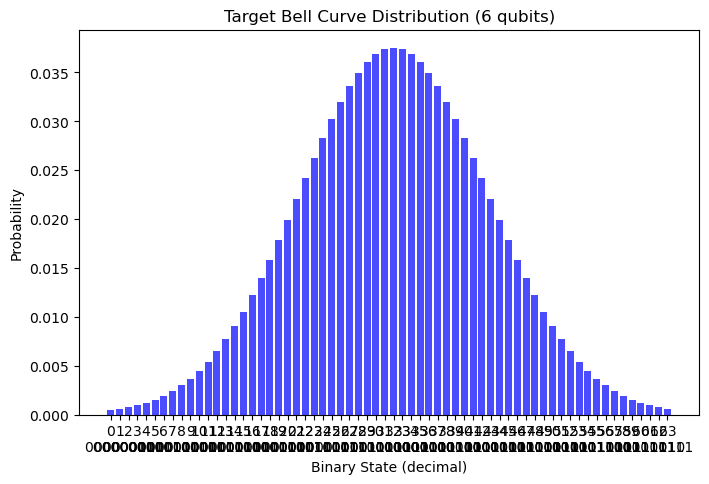

Target entropy: 3.7699
Starting scalable training...
Iteration 0: Loss = 0.129220, LR = 0.0800
Iteration 30: Loss = 0.100516, LR = 0.0800
Iteration 30: Loss = 0.100516, LR = 0.0800
Iteration 60: Loss = 0.080468, LR = 0.0640
Iteration 60: Loss = 0.080468, LR = 0.0640
Iteration 90: Loss = 0.065524, LR = 0.0640
Iteration 90: Loss = 0.065524, LR = 0.0640
Iteration 120: Loss = 0.058024, LR = 0.0512
Iteration 120: Loss = 0.058024, LR = 0.0512
Iteration 150: Loss = 0.050175, LR = 0.0512
Iteration 150: Loss = 0.050175, LR = 0.0512
Iteration 180: Loss = 0.046081, LR = 0.0410
Iteration 180: Loss = 0.046081, LR = 0.0410
Iteration 210: Loss = 0.043677, LR = 0.0328
Iteration 210: Loss = 0.043677, LR = 0.0328
Iteration 240: Loss = 0.041911, LR = 0.0328
Iteration 240: Loss = 0.041911, LR = 0.0328
Iteration 270: Loss = 0.040726, LR = 0.0262
Iteration 270: Loss = 0.040726, LR = 0.0262
Iteration 300: Loss = 0.040708, LR = 0.0262
Iteration 300: Loss = 0.040708, LR = 0.0262
Iteration 330: Loss = 0.038790,

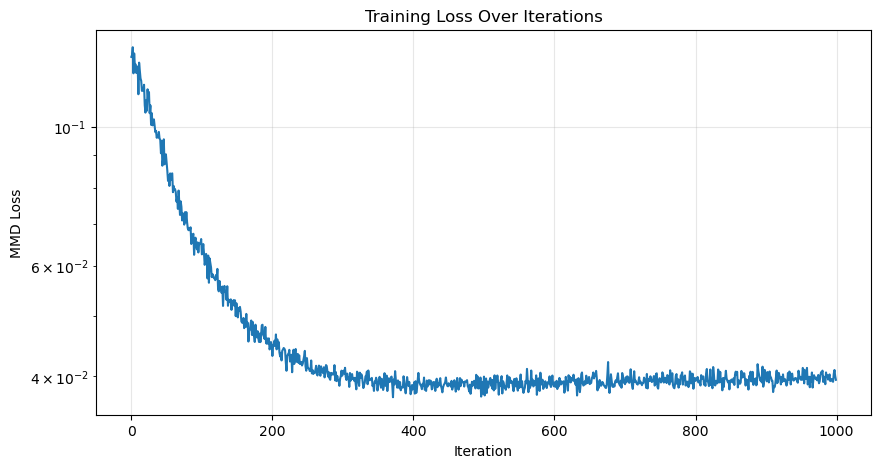


Training completed!
Final loss: 0.039514

Model Evaluation:
MMD Loss: 0.038762
KL Divergence: 1.1733


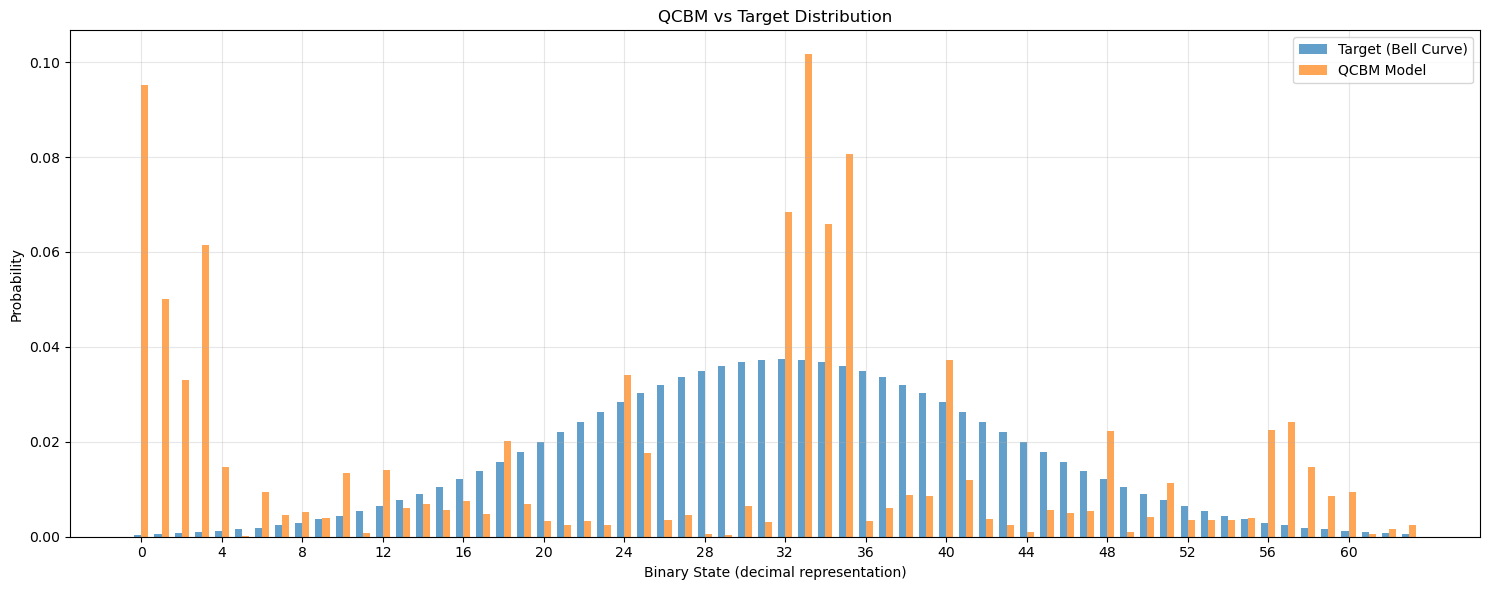


Testing Y-basis measurements...


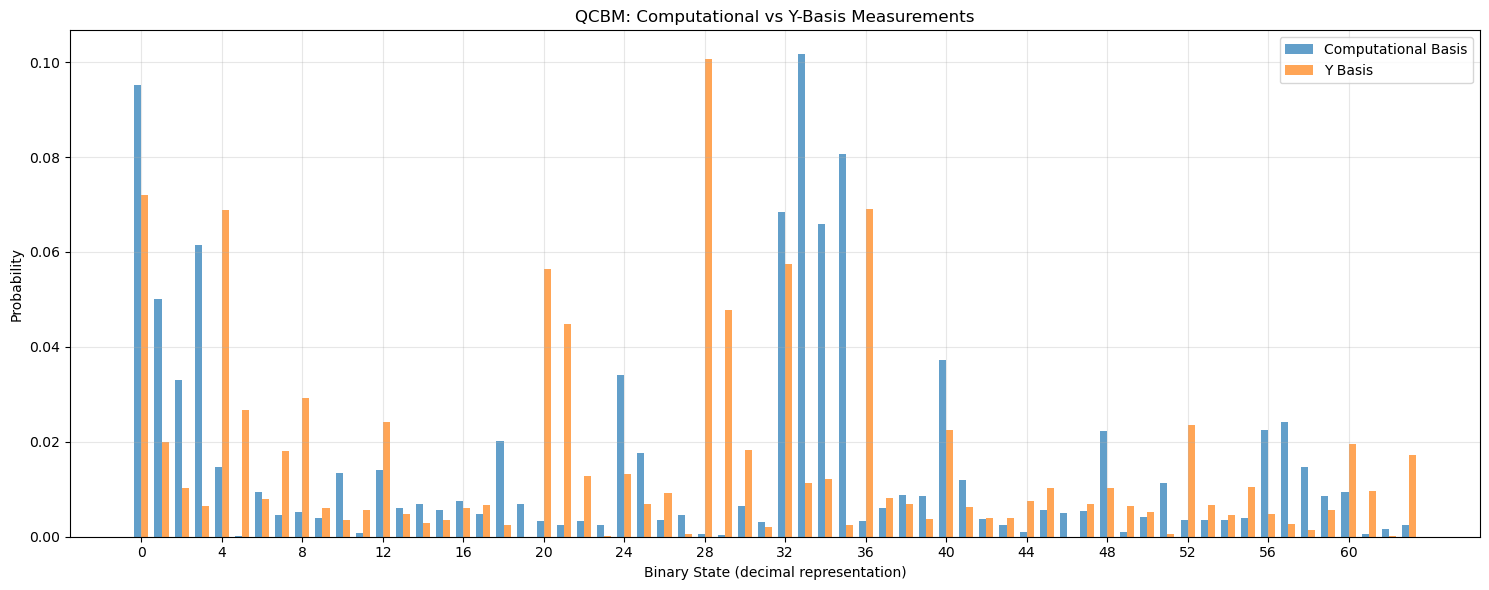

In [3]:
# Scaling up the training to what the paper uses
import numpy as np
import matplotlib.pyplot as plt

# Set your desired number of qubits/layers for scaling up (overwrite at the top if needed)
# num_qubits = 6
num_layers = 2
num_samples = 8000

# Calculate number of parameters for the all-to-all entanglement ansatz
params_per_layer = 2 * num_qubits + (num_qubits * (num_qubits - 1)) // 2
total_params = num_layers * params_per_layer
print(f"Total parameters: {total_params}")

def generate_simple_bell_curve(num_bits):
    num_states = 2**num_bits
    center = num_states // 2
    states = np.arange(num_states)
    sigma = num_states / 6
    probs = np.exp(-(states - center)**2 / (2 * sigma**2))
    probs = probs / np.sum(probs)
    return probs

def mmd_loss(target_probs, model_probs):
    return np.sum((target_probs - model_probs)**2)

def train_qcbm_scalable(target_probs, num_iterations=300, base_lr=0.08, momentum_rate=0.3):
    params = np.random.uniform(-np.pi/6, np.pi/6, total_params)
    learning_rate = base_lr
    losses = []
    best_params = params.copy()
    best_loss = float('inf')
    print("Starting scalable training...")
    for iteration in range(num_iterations):
        current_probs = circuit(params)
        loss = mmd_loss(target_probs, current_probs)
        losses.append(loss)
        if loss < best_loss:
            best_loss = loss
            best_params = params.copy()
        if iteration % 30 == 0:
            print(f"Iteration {iteration}: Loss = {loss:.6f}, LR = {learning_rate:.4f}")
        gradients = np.zeros_like(params)
        for i in range(len(params)):
            shift = np.pi / 2
            params_plus = params.copy()
            params_plus[i] += shift
            probs_plus = circuit(params_plus)
            loss_plus = mmd_loss(target_probs, probs_plus)
            params_minus = params.copy()
            params_minus[i] -= shift
            probs_minus = circuit(params_minus)
            loss_minus = mmd_loss(target_probs, probs_minus)
            gradients[i] = (loss_plus - loss_minus) / 2
        if iteration == 0:
            momentum = np.zeros_like(params)
        momentum = momentum_rate * momentum + learning_rate * gradients
        params -= momentum
        if iteration > 0 and iteration % 50 == 0:
            learning_rate *= 0.8
        if loss < 1e-4:
            print(f"Early stopping at iteration {iteration}")
            break
    return best_params, losses

def plot_training_progress(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss Over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('MMD Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_distributions_scalable(target_probs, model_probs, title="QCBM vs Target Distribution"):
    num_states = len(target_probs)
    x = range(num_states)
    width = 0.35
    plt.figure(figsize=(15, 6))
    plt.bar([i - width/2 for i in x], target_probs, width, alpha=0.7, label='Target (Bell Curve)')
    plt.bar([i + width/2 for i in x], model_probs, width, alpha=0.7, label='QCBM Model')
    plt.xlabel('Binary State (decimal representation)')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    if num_states <= 16:
        plt.xticks(x, [f'{i}\n({format(i, f"0{num_qubits}b")})' for i in x], fontsize=8)
    else:
        tick_indices = list(range(0, num_states, max(1, num_states//16)))
        plt.xticks(tick_indices, [f'{i}' for i in tick_indices])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(params, target_probs):
    model_probs = circuit(params)
    mmd = mmd_loss(target_probs, model_probs)
    epsilon = 1e-8
    model_smooth = model_probs + epsilon
    model_smooth = model_smooth / np.sum(model_smooth)
    kl_div = np.sum(target_probs * np.log((target_probs + epsilon) / model_smooth))
    print(f"\nModel Evaluation:")
    print(f"MMD Loss: {mmd:.6f}")
    print(f"KL Divergence: {kl_div:.4f}")
    return model_probs

# Main training script
print(f"Training QCBM with {num_qubits} qubits, {num_layers} layer(s)")
print(f"Parameter count: {total_params}")

# Generate target distribution
target_probs = generate_simple_bell_curve(num_qubits)

# Plot target distribution
plt.figure(figsize=(8, 5))
states = range(len(target_probs))
plt.bar(states, target_probs, alpha=0.7, color='blue')
plt.title(f'Target Bell Curve Distribution ({num_qubits} qubits)')
plt.xlabel('Binary State (decimal)')
plt.ylabel('Probability')
plt.xticks(states, [f'{i}\n{format(i, f"0{num_qubits}b")}' for i in states])
plt.show()

print(f"Target entropy: {-np.sum(target_probs * np.log(target_probs + 1e-8)):.4f}")

# Train QCBM
trained_params, losses = train_qcbm_scalable(target_probs, num_iterations=1000, base_lr=0.08, momentum_rate=0.3)

# Plot training progress
plot_training_progress(losses)

print(f"\nTraining completed!")
print(f"Final loss: {losses[-1]:.6f}")

# Evaluate and plot results
model_probs = evaluate_model(trained_params, target_probs)
plot_distributions_scalable(target_probs, model_probs)

# Test multi-basis capability (like the paper)
print("\nTesting Y-basis measurements...")
y_basis_probs = circuit(trained_params, basis="Y")

plt.figure(figsize=(15, 6))
x = range(len(model_probs))
width = 0.35
plt.bar([i - width/2 for i in x], model_probs, width, alpha=0.7, label='Computational Basis')
plt.bar([i + width/2 for i in x], y_basis_probs, width, alpha=0.7, label='Y Basis')
plt.xlabel('Binary State (decimal representation)')
plt.ylabel('Probability')
plt.title('QCBM: Computational vs Y-Basis Measurements')
plt.legend()
if len(model_probs) <= 16:
    plt.xticks(x, [f'{i}' for i in x])
else:
    tick_indices = list(range(0, len(model_probs), max(1, len(model_probs)//16)))
    plt.xticks(tick_indices, [f'{i}' for i in tick_indices])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()